In [3]:
!pip install torch torchvision

In [4]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from scipy.stats import entropy

# Thêm thư mục gốc vào path để import src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.utils import load_cifar10_longtail
from src.model import hierarchical_kmeans_resampling
from src.metrics import calculate_acc, calculate_nmi # Đảm bảo bạn đã có hàm này trong metrics.py

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hệ thống sẵn sàng. Thiết bị sử dụng: {device}")

Hệ thống sẵn sàng. Thiết bị sử dụng: cpu


Đã load xong đặc trưng: (20431, 384)
Đã load xong nhãn Long-tail: (20431,)


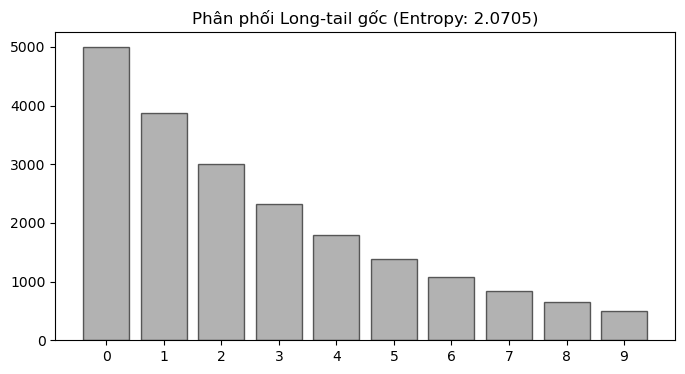

In [5]:
# 1. Thêm đường dẫn src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.model import hierarchical_kmeans_resampling
from src.metrics import calculate_acc, calculate_nmi

# 2. Load dữ liệu từ folder processed (Dùng đúng tên file trong ảnh của bạn)
X_feats_raw = np.load('../data/processed/X_features_cifar_0.1.npy')
Y_longtail = np.load('../data/processed/Y_longtail_cifar_0.1.npy')

# 3. Chuẩn hóa L2 (Cực kỳ quan trọng để K-means chạy chuẩn trên đặc trưng DINOv2)
X_feats_norm = normalize(X_feats_raw)

print(f"Đã load xong đặc trưng: {X_feats_norm.shape}")
print(f"Đã load xong nhãn Long-tail: {Y_longtail.shape}")

# Trực quan hóa phân phối Long-tail ban đầu
classes, counts = np.unique(Y_longtail, return_counts=True)
ent_raw = entropy(counts/len(Y_longtail))
plt.figure(figsize=(8, 4))
plt.bar(classes, counts, color='gray', alpha=0.6, edgecolor='black')
plt.title(f"Phân phối Long-tail gốc (Entropy: {ent_raw:.4f})")
plt.xticks(range(10))
plt.show()

In [17]:
k_list = [2000, 500, 100] 
r_t_list = [5, 2, 1] 

print("Đang chạy Hierarchical K-means Resampling...")
centroids_final = hierarchical_kmeans_resampling(
    X_feats_norm, k_list, T=3, m=10, r_t_list=r_t_list, num_init=5
)

# Gán nhãn cụm cho toàn bộ ảnh
km_final = KMeans(n_clusters=100, init=centroids_final, n_init=1).fit(X_feats_norm)
cluster_labels = km_final.labels_

Đang chạy Hierarchical K-means Resampling...
--- Level 1/3 (k=2000, r_t=5) ---
--- Level 2/3 (k=500, r_t=2) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 3/3 (k=100, r_t=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

Đang tính toán các chỉ số cho 2446 mẫu...


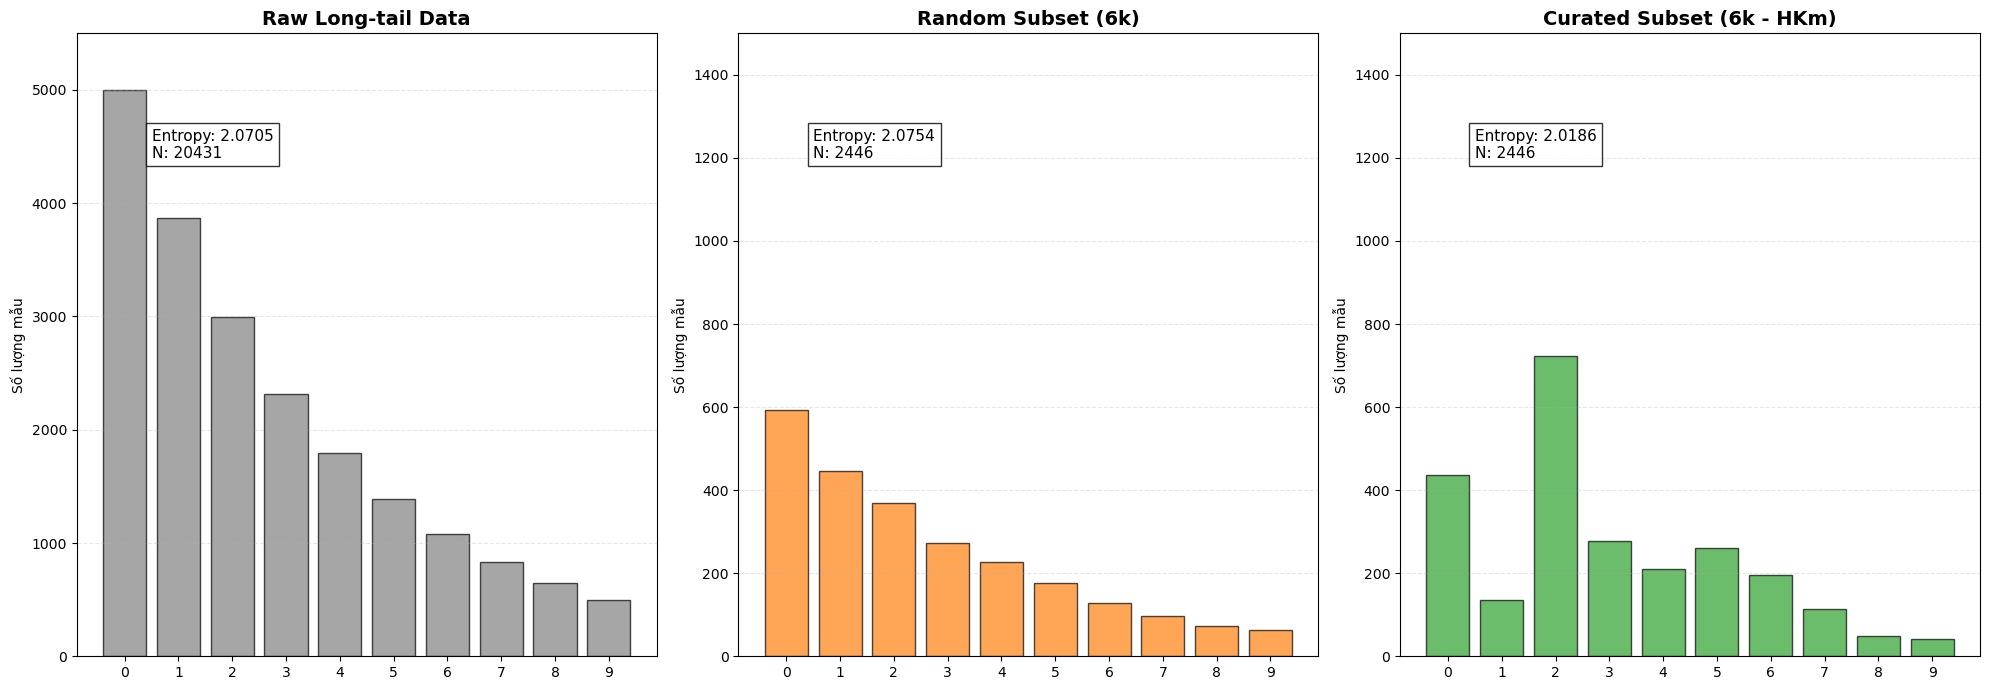

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

np.random.seed(42)

idx_curated = []
N_PER_CLUSTER = 40 

for i in range(100): 
    cluster_idx = np.where(cluster_labels == i)[0]
    if len(cluster_idx) == 0: continue
    

    n_draw = min(len(cluster_idx), N_PER_CLUSTER)
    pick = np.random.choice(cluster_idx, n_draw, replace=False)
    idx_curated.extend(pick)

idx_curated = np.array(idx_curated)
X_curated_feats = X_feats_norm[idx_curated]
Y_curated_subset = Y_longtail[idx_curated]

N_SAMPLES_TOTAL = len(idx_curated)
idx_random = np.random.choice(len(Y_longtail), N_SAMPLES_TOTAL, replace=False)
X_random_feats = X_feats_norm[idx_random]
Y_random_subset = Y_longtail[idx_random]

# --- 3. Tính toán các chỉ số ---
print(f"Đang tính toán các chỉ số cho {N_SAMPLES_TOTAL} mẫu...")

# A. Entropy (Độ cân bằng nhãn)
ent_raw = entropy(np.unique(Y_longtail, return_counts=True)[1] / len(Y_longtail))
ent_rand = entropy(np.unique(Y_random_subset, return_counts=True)[1] / len(Y_random_subset))
ent_ours = entropy(np.unique(Y_curated_subset, return_counts=True)[1] / len(Y_curated_subset))


# --- 4. VẼ BIỂU ĐỒ SO SÁNH ---
def plot_high_scale_comparison(y, title, color, ent, y_limit):
    cls, cnt = np.unique(y, return_counts=True)
    full_cnt = np.zeros(10); full_cnt[cls] = cnt
    plt.bar(range(10), full_cnt, color=color, alpha=0.7, edgecolor='black')
    
    # Ghi chỉ số
    stats_text = f"Entropy: {ent:.4f}\nN: {len(y)}"
    plt.text(0.5, y_limit*0.8, stats_text, fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylim(0, y_limit)
    plt.xticks(range(10))
    plt.ylabel("Số lượng mẫu")
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.figure(figsize=(20, 7))

# Subplot 1: Bể dữ liệu thô (20k ảnh)
plt.subplot(1, 3, 1)
plot_high_scale_comparison(Y_longtail, "Raw Long-tail Data", "gray", ent_raw, 5500)

# Subplot 2: Random Subset (6k ảnh)
plt.subplot(1, 3, 2)
plot_high_scale_comparison(Y_random_subset, "Random Subset (6k)", "tab:orange", ent_rand, 1500)

# Subplot 3: Curated Subset (6k ảnh - HK-means)
plt.subplot(1, 3, 3)
plot_high_scale_comparison(Y_curated_subset, "Curated Subset (6k - HKm)", "tab:green", ent_ours, 1500)

plt.tight_layout()
plt.show()

In [9]:
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from PIL import Image

# Định nghĩa lại Class Dataset để DataLoader có thể đọc được mảng ảnh
class CifarDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]

        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img

def extract_features_fast(X_images, batch_size=64):
    """
    Hàm trích xuất đặc trưng bằng DINOv2 theo từng Batch để tối ưu tốc độ.
    """
    dataset = CifarDataset(X_images, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    feats = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Đang trích xuất đặc trưng"):
            # 'model' và 'device' đã được định nghĩa ở các Cell setup phía trên
            batch = batch.to(device)
            feat = model(batch)
            feats.append(feat.cpu().numpy())
            
    return np.vstack(feats)

In [10]:
import importlib
import src.utils
importlib.reload(src.utils)
from src.utils import load_cifar10_test # Dùng tên mới cho rõ ràng

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

if 'model' not in locals():
    print("Đang tải mô hình DINOv2...")
    model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
    model.eval()
    print("Tải mô hình thành công!")
# 1. Load tập Test chuẩn (10.000 ảnh)
X_test_img, Y_test = load_cifar10_test('../data/cifar-10-batches-py')

# 2. Trích xuất đặc trưng cho tập Test (Dùng hàm fast có thanh process)
# Bước này mất khoảng 5-8 phút tùy máy
X_test_feats = extract_features_fast(X_test_img, batch_size=128)
X_test_feats = normalize(X_test_feats) 

print(f"Đã chuẩn bị xong đặc trưng tập Test: {X_test_feats.shape}")

Đang tải mô hình DINOv2...


Using cache found in C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Tải mô hình thành công!


Đang trích xuất đặc trưng: 100%|██████████| 79/79 [09:34<00:00,  7.28s/it]


Đã chuẩn bị xong đặc trưng tập Test: (10000, 384)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

# Đảm bảo các biến sau đã tồn tại: 
# X_feats_norm (Train features), Y_longtail (Train labels)
# X_test_feats (Test features), Y_test (Test labels)
# idx_curated (Chỉ số tập đã lọc)

# --- 1. Huấn luyện trên TOÀN BỘ bể dữ liệu Long-tail (N ~ 20.000) ---
print(f"Đang huấn luyện trên FULL Long-tail (N={len(X_feats_norm)})...")
clf_full = LogisticRegression(max_iter=1000).fit(X_feats_norm, Y_longtail)
Y_pred_full = clf_full.predict(X_test_feats)

# --- 2. Huấn luyện trên tập Random (N = 1143 hoặc tùy cấu hình của bạn) ---
N_samples = len(idx_curated)
np.random.seed(42)
rand_idx = np.random.choice(len(X_feats_norm), N_samples, replace=False)

print(f"Đang huấn luyện trên Random Subset (N={N_samples})...")
clf_rand = LogisticRegression(max_iter=1000).fit(X_feats_norm[rand_idx], Y_longtail[rand_idx])
Y_pred_rand = clf_rand.predict(X_test_feats)

# --- 3. Huấn luyện trên tập Curated (N = 1143) ---
print(f"Đang huấn luyện trên Curated Subset (N={N_samples})...")
clf_curated = LogisticRegression(max_iter=1000).fit(X_feats_norm[idx_curated], Y_longtail[idx_curated])
Y_pred_curated = clf_curated.predict(X_test_feats)

Đang huấn luyện trên FULL Long-tail (N=20431)...
Đang huấn luyện trên Random Subset (N=2622)...
Đang huấn luyện trên Curated Subset (N=2622)...


In [12]:
from src.metrics import calculate_acc, calculate_nmi # Đảm bảo đã có trong file metrics.py
from sklearn.metrics import adjusted_rand_score

# 1. Tính toán 3 chỉ số theo yêu cầu của giảng viên
# cluster_labels là nhãn thu được từ HK-means
acc_cluster = calculate_acc(Y_longtail, cluster_labels)
nmi_cluster = calculate_nmi(Y_longtail, cluster_labels)
ari_cluster = adjusted_rand_score(Y_longtail, cluster_labels)

# 2. Tổng hợp bảng đánh giá Phân cụm (Clustering Quality)
clustering_metrics = pd.DataFrame({
    "Độ đo": ["Accuracy (Hungarian)", "NMI", "ARI"],
    "Kết quả": [acc_cluster, nmi_cluster, ari_cluster],
})

print("--- BẢNG 1: ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM (YÊU CẦU 3.2.4) ---")
print(clustering_metrics.round(4))

--- BẢNG 1: ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM (YÊU CẦU 3.2.4) ---
                  Độ đo  Kết quả
0  Accuracy (Hungarian)   0.2459
1                   NMI   0.5819
2                   ARI   0.2098


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

# --- 1. Huấn luyện trên FULL Long-tail (N=20431) ---
clf_full = LogisticRegression(max_iter=1000).fit(X_feats_norm, Y_longtail)
Y_pred_full = clf_full.predict(X_test_feats)

# --- 2. Huấn luyện trên tập Random Subset ---
N_samples = len(idx_curated)
np.random.seed(42)
rand_idx = np.random.choice(len(X_feats_norm), N_samples, replace=False)
clf_rand = LogisticRegression(max_iter=1000).fit(X_feats_norm[rand_idx], Y_longtail[rand_idx])
Y_pred_rand = clf_rand.predict(X_test_feats)

# --- 3. Huấn luyện trên tập Curated Subset (Ours) ---
clf_ours = LogisticRegression(max_iter=1000).fit(X_feats_norm[idx_curated], Y_longtail[idx_curated])
Y_pred_ours = clf_ours.predict(X_test_feats)

# --- 4. TỔNG HỢP KẾT QUẢ ---
results = {
    "Dataset": ["Full Long-tail (Thô)", "Random Subset", "Curated Subset (Ours)"],
    "Kích thước (N)": [len(Y_longtail), N_samples, N_samples],
    "Accuracy": [
        accuracy_score(Y_test, Y_pred_full),
        accuracy_score(Y_test, Y_pred_rand),
        accuracy_score(Y_test, Y_pred_ours)
    ],
    "Macro F1-Score": [
        f1_score(Y_test, Y_pred_full, average='macro'),
        f1_score(Y_test, Y_pred_rand, average='macro'),
        f1_score(Y_test, Y_pred_ours, average='macro')
    ]
}

df_res = pd.DataFrame(results)
print("\n--- BẢNG 2: SO SÁNH HIỆU NĂNG HUẤN LUYỆN ---")
print(df_res.round(4))


--- BẢNG 2: SO SÁNH HIỆU NĂNG HUẤN LUYỆN ---
                 Dataset  Kích thước (N)  Accuracy  Macro F1-Score
0   Full Long-tail (Thô)           20431    0.9430          0.9431
1          Random Subset            2622    0.9068          0.9064
2  Curated Subset (Ours)            2622    0.9030          0.9025


In [22]:
import time
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, adjusted_rand_score
from src.metrics import calculate_acc, calculate_nmi
import matplotlib.pyplot as plt

# --- CẤU HÌNH GRID TEST ---
configs = [
    {"name": "3-Levels", "k_list": [2000, 500, 100], "r_t_list": [5, 2, 1]},
    {"name": "2-Levels", "k_list": [500, 100], "r_t_list": [2, 1]}
]
budget_sizes = [500, 1000, 2000, 3000, 5000]

grid_results = []

for config in configs:
    print(f"\n===== ĐANG THỬ NGHIỆM CẤU HÌNH: {config['name']} {config['k_list']} =====")
    
    # 1. Chạy phân cụm HK-means (Chỉ chạy 1 lần cho mỗi k_list)
    t0_cluster = time.time()
    centroids_final = hierarchical_kmeans_resampling(
        X_feats_norm, 
        k_list=config['k_list'], 
        T=len(config['k_list']), 
        m=10, 
        r_t_list=config['r_t_list'], 
        num_init=3
    )
    
    # Gán nhãn cho tầng cuối (k=100) để đánh giá chất lượng phân cụm
    k_final = config['k_list'][-1]
    km_final = KMeans(n_clusters=k_final, init=centroids_final, n_init=1).fit(X_feats_norm)
    cluster_labels = km_final.labels_
    t1_cluster = time.time()
    
    # 2. Tính các độ đo PHÂN CỤM (Yêu cầu 3.2.4)
    # Tính trên toàn bộ tập dữ liệu huấn luyện
    nmi_cluster = calculate_nmi(Y_longtail, cluster_labels)
    ari_cluster = adjusted_rand_score(Y_longtail, cluster_labels)
    acc_cluster = calculate_acc(Y_longtail, cluster_labels)
    
    print(f"-> Phân cụm xong. NMI: {nmi_cluster:.4f} | ACC: {acc_cluster:.4f} | ARI: {ari_cluster:.4f}")

    # 3. Vòng lặp thử nghiệm các mức dung lượng dữ liệu N
    for N in budget_sizes:
        print(f"   Đang đánh giá hiệu năng huấn luyện với N = {N}...")
        
        # --- A. Lấy mẫu Ngẫu nhiên (Random Baseline) ---
        np.random.seed(42)
        idx_random = np.random.choice(len(X_feats_norm), N, replace=False)
        clf_rand = LogisticRegression(max_iter=500).fit(X_feats_norm[idx_random], Y_longtail[idx_random])
        y_pred_r = clf_rand.predict(X_test_feats)
        
        f1_rand = f1_score(Y_test, y_pred_r, average='macro')
        acc_test_rand = accuracy_score(Y_test, y_pred_r)

        # --- B. Lấy mẫu Curated (HK-means) ---
        n_per_c = N // k_final
        idx_curated = []
        for i in range(k_final):
            c_idx = np.where(cluster_labels == i)[0]
            if len(c_idx) == 0: continue
            # Lấy ngẫu nhiên bên trong cụm (Strategy 'r')
            n_draw = min(len(c_idx), n_per_c)
            idx_curated.extend(np.random.choice(c_idx, n_draw, replace=False))
        
        idx_curated = np.array(idx_curated)
        actual_n = len(idx_curated) # Số lượng mẫu thực tế lấy được
        
        # Huấn luyện trên tập Curated
        clf_ours = LogisticRegression(max_iter=500).fit(X_feats_norm[idx_curated], Y_longtail[idx_curated])
        y_pred_o = clf_ours.predict(X_test_feats)
        
        f1_ours = f1_score(Y_test, y_pred_o, average='macro')
        acc_test_ours = accuracy_score(Y_test, y_pred_o)

        # Lưu kết quả vào danh sách
        grid_results.append({
            "Hierarchy": config['name'],
            "Target_N": N,
            "Actual_N": actual_n,
            "Clust_NMI": nmi_cluster,
            "Clust_ACC": acc_cluster,
            "Clust_ARI": ari_cluster,
            "Rand_Test_ACC": acc_test_rand,
            "Curated_Test_ACC": acc_test_ours,
            "Rand_F1": f1_rand,
            "Curated_F1": f1_ours
        })

# --- XUẤT KẾT QUẢ ---
df_grid = pd.DataFrame(grid_results)

# Sắp xếp lại thứ tự cột cho chuyên nghiệp
cols = [
    "Hierarchy", "Target_N", "Actual_N", 
    "Clust_NMI", "Clust_ACC", "Clust_ARI", 
    "Rand_Test_ACC", "Curated_Test_ACC", 
    "Rand_F1", "Curated_F1"
]
df_grid = df_grid[cols]

print("\n" + "="*110)
print("BẢNG TỔNG HỢP KẾT QUẢ GRID TEST (REPRODUCTION & ABLATION)")
print("="*110)
print(df_grid.to_string(index=False))


===== ĐANG THỬ NGHIỆM CẤU HÌNH: 3-Levels [2000, 500, 100] =====
--- Level 1/3 (k=2000, r_t=5) ---
--- Level 2/3 (k=500, r_t=2) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 3/3 (k=100, r_t=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

-> Phân cụm xong. NMI: 0.5796 | ACC: 0.2206 | ARI: 0.1793
   Đang đánh giá hiệu năng huấn luyện với N = 500...
   Đang đánh giá hiệu năng huấn luyện với N = 1000...
   Đang đánh giá hiệu năng huấn luyện với N = 2000...
   Đang đánh giá hiệu năng huấn luyện với N = 3000...
   Đang đánh giá hiệu năng huấn luyện với N = 5000...

===== ĐANG THỬ NGHIỆM CẤU HÌNH: 2-Levels [500, 100] =====
--- Level 1/2 (k=500, r_t=2) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 2/2 (k=100, r_t=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

-> Phân cụm xong. NMI: 0.5534 | ACC: 0.1809 | ARI: 0.1469
   Đang đánh giá hiệu năng huấn luyện với N = 500...
   Đang đánh giá hiệu năng huấn luyện với N = 1000...
   Đang đánh giá hiệu năng huấn luyện với N = 2000...
   Đang đánh giá hiệu năng huấn luyện với N = 3000...
   Đang đánh giá hiệu năng huấn luyện với N = 5000...

BẢNG TỔNG HỢP KẾT QUẢ GRID TEST (REPRODUCTION & ABLATION)
Hierarchy  Target_N  Actual_N  Clust_NMI  Clust_ACC  Clust_ARI  Rand_Test_ACC  Curated_Test_ACC  Rand_F1  Curated_F1
 3-Levels       500       361   0.579614   0.220645   0.179262         0.7881            0.7334 0.768996    0.702855
 3-Levels      1000       681   0.579614   0.220645   0.179262         0.8730            0.8192 0.871374    0.808646
 3-Levels      2000      1313   0.579614   0.220645   0.179262         0.9021            0.8761 0.901546    0.873171
 3-Levels      3000      1943   0.579614   0.220645   0.179262         0.9109            0.8977 0.910638    0.896685
 3-Levels      5000      3203